In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("amostra.csv")

df.head()

,Nº na população,Nº da amostra,Preço,Dias de antecedência,Duração (min),Escalas,Quantidade de voos disponíveis,Companhia Aerea
0,45,1,"R$ 3.853,00",7,410,1,103,LATAM
1,181,2,"R$ 3.967,00",15,1265,1,110,LATAM
2,82,3,"R$ 4.000,00",7,1540,1,103,LATAM
3,8,4,"R$ 1.555,00",7,1785,1,103,LATAM
4,55,5,"R$ 3.967,00",7,780,1,103,LATAM


In [4]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Nº na população', 'Nº da amostra', 'Preço', 'Dias de antecedência', 'Duração (min)', 'Escalas', 'Quantidade de voos disponíveis', 'Companhia Aerea']


In [5]:
import numpy as np
import pandas as pd

def limpar_preco(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor)
    valor = valor.replace("R$", "")
    valor = valor.replace(".", "")
    valor = valor.replace(",", ".")
    valor = valor.strip()

    return pd.to_numeric(valor, errors="coerce")


dados = pd.DataFrame()

dados["preco"] = df["Preço"].apply(limpar_preco)
dados["antecedencia"] = pd.to_numeric(df["Dias de antecedência"], errors="coerce")
dados["duracao"] = pd.to_numeric(df["Duração (min)"], errors="coerce")
dados["escalas"] = pd.to_numeric(df["Escalas"], errors="coerce")
dados["qtd_voos"] = pd.to_numeric(df["Quantidade de voos disponíveis"], errors="coerce")

dados = dados.dropna()

dados.head()

,preco,antecedencia,duracao,escalas,qtd_voos
0,3853.0,7,410,1,103
1,3967.0,15,1265,1,110
2,4000.0,7,1540,1,103
3,1555.0,7,1785,1,103
4,3967.0,7,780,1,103


In [9]:
import numpy as np
import pandas as pd

def cronbach_alpha_padronizado(dados):
    """
    Calcula o Alfa de Cronbach padronizado
    usando a matriz de correlação entre as variáveis.
    """
    matriz_corr = dados.corr()

    k = len(matriz_corr.columns)

    if k < 2:
        return np.nan

    correlacoes = matriz_corr.values[np.triu_indices(k, 1)]

    media_corr = np.mean(correlacoes)

    alpha = (k * media_corr) / (1 + (k - 1) * media_corr)

    return alpha

In [10]:
alpha_geral = cronbach_alpha_padronizado(dados)

print("Alfa de Cronbach padronizado geral:")
print(round(alpha_geral, 4))

Alfa de Cronbach padronizado geral:
-0.3053


In [11]:
resultados = []

for coluna in dados.columns:
    dados_sem_variavel = dados.drop(columns=[coluna])
    alpha_sem = cronbach_alpha_padronizado(dados_sem_variavel)

    resultados.append({
        "Variável retirada": coluna,
        "Alfa padronizado sem a variável": round(alpha_sem, 4)
    })

resultado_df = pd.DataFrame(resultados)

resultado_df

,Variável retirada,Alfa padronizado sem a variável
0,preco,-0.5180
1,antecedencia,0.0381
2,duracao,0.0030
3,escalas,-1.1308
4,qtd_voos,-0.0399


In [12]:
tabela_final = pd.DataFrame({
    "Análise": ["Alfa geral"],
    "Alfa de Cronbach padronizado": [round(alpha_geral, 4)]
})

for _, linha in resultado_df.iterrows():
    tabela_final.loc[len(tabela_final)] = [
        f"Sem {linha['Variável retirada']}",
        linha["Alfa padronizado sem a variável"]
    ]

tabela_final

,Análise,Alfa de Cronbach padronizado
0,Alfa geral,-0.3053
1,Sem preco,-0.5180
2,Sem antecedencia,0.0381
3,Sem duracao,0.0030
4,Sem escalas,-1.1308
5,Sem qtd_voos,-0.0399


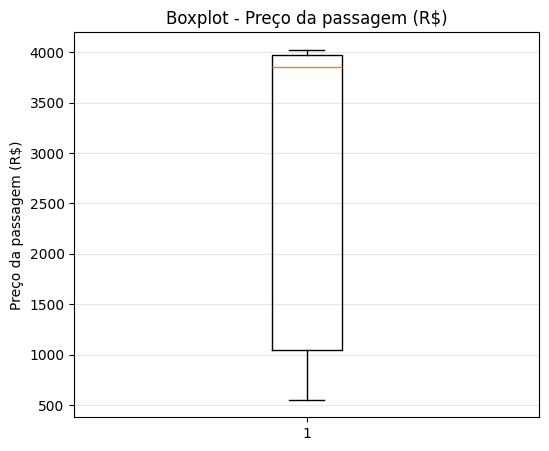

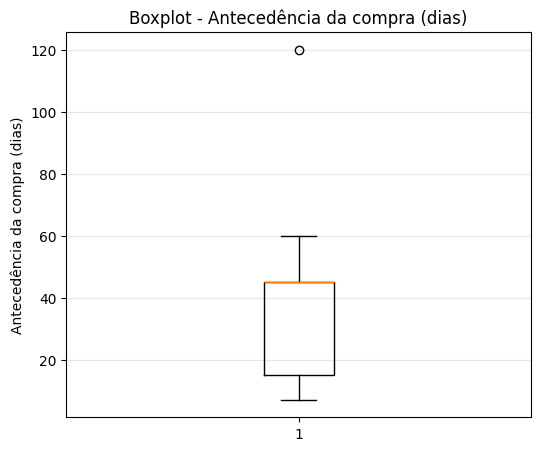

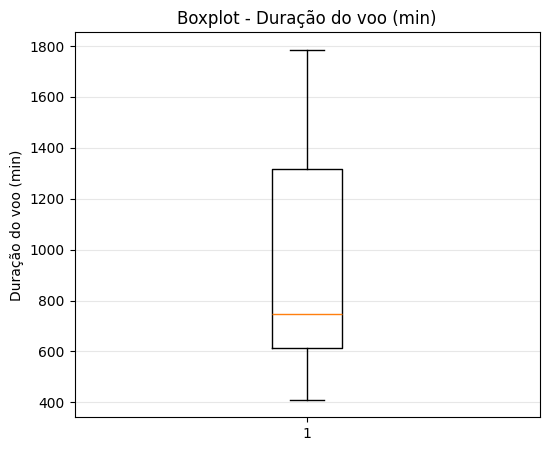

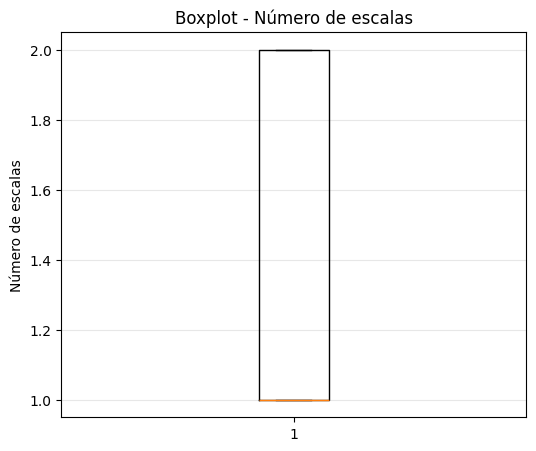

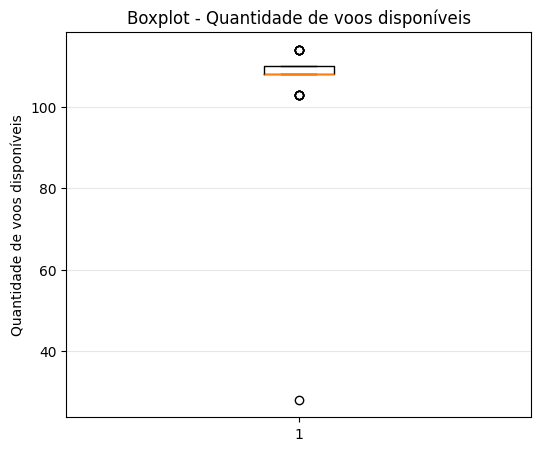

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_csv("amostra.csv")
df.columns = df.columns.str.strip()

def limpar_preco(valor):
    if pd.isna(valor):
        return np.nan
    valor = str(valor)
    valor = valor.replace("R$", "")
    valor = valor.replace(".", "")
    valor = valor.replace(",", ".")
    valor = valor.strip()
    return pd.to_numeric(valor, errors="coerce")

dados = pd.DataFrame()
dados["Preço da passagem (R$)"] = df["Preço"].apply(limpar_preco)
dados["Antecedência da compra (dias)"] = pd.to_numeric(df["Dias de antecedência"], errors="coerce")
dados["Duração do voo (min)"] = pd.to_numeric(df["Duração (min)"], errors="coerce")
dados["Número de escalas"] = pd.to_numeric(df["Escalas"], errors="coerce")
dados["Quantidade de voos disponíveis"] = pd.to_numeric(df["Quantidade de voos disponíveis"], errors="coerce")

dados = dados.dropna()

os.makedirs("boxplots", exist_ok=True)

for coluna in dados.columns:
    plt.figure(figsize=(6, 5))
    plt.boxplot(dados[coluna], vert=True)
    plt.title(f"Boxplot - {coluna}")
    plt.ylabel(coluna)
    plt.grid(axis="y", alpha=0.3)

    nome_arquivo = coluna.lower()
    nome_arquivo = nome_arquivo.replace(" ", "_")
    nome_arquivo = nome_arquivo.replace("(", "")
    nome_arquivo = nome_arquivo.replace(")", "")
    nome_arquivo = nome_arquivo.replace("ç", "c")
    nome_arquivo = nome_arquivo.replace("ã", "a")
    nome_arquivo = nome_arquivo.replace("ê", "e")
    nome_arquivo = nome_arquivo.replace("í", "i")
    nome_arquivo = nome_arquivo.replace("á", "a")

    plt.savefig(f"boxplots/{nome_arquivo}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [2]:
%pip install statsmodels scipy

  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----------------- ---------------------- 4.2/9.5 MB 28.1 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 27.0 MB/s eta 0:00:00
Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl (36.5 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install matplotlib

  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 2.4 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.2 MB 2.5 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.2 MB 2.5 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.2 MB 2.1 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.2 MB 1.8 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.2 MB 1.8 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.2 MB 1.6 MB/s eta 0:00:04
   ------------ --------------------------- 2.6/8.2 MB 1.5 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.2 MB 1.5 MB/s eta 0:00:04
   --------------- ------------------------ 3.1/8.2 MB 1.4 MB/s eta 0:00:04
   --------------- -----------------


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
